<a href="https://colab.research.google.com/github/NikhilReddy359/CreatorSpaceLabIntern/blob/main/Student_Placement_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Analytics for Student Placement Success
### End-to-End Machine Learning Project

**Goal:** Predict whether a student will be placed, based on academic scores, CGPA, backlogs, internships/projects, communication skill, aptitude score, department, and work experience.

**Dataset columns:** `student_id`, `gender`, `department`, `ssc_p`, `hsc_p`, `cgpa`, `backlogs`, `internships`, `projects_completed`, `communication_skill`, `aptitude_score`, `workex`, `status`, `salary`

**Steps covered:**
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Train-Test Split
6. Model Building (Logistic Regression, Decision Tree, Random Forest) with cross-validation
7. Model Evaluation
8. Feature Importance & Insights
9. Predict on New Student Data


## Step 1: Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
%matplotlib inline


## Step 2: Load Dataset

Upload `Engineering_Placement_Data.csv` to Colab (or place it in the same folder as this notebook), then load it below.


In [24]:
df = pd.read_csv("Engineering_Placement_Data.csv")
df = df.drop(columns=['student_id'])
print("Shape:", df.shape)
df.head()


Shape: (400, 13)


,gender,department,ssc_p,hsc_p,cgpa,backlogs,internships,projects_completed,communication_skill,aptitude_score,workex,status,salary
0,F,CSE,79.23,82.14,7.43,2,2,3,7,68.73,No,Placed,313000.0
1,M,Civil,59.53,56.60,9.21,0,1,2,5,71.82,Yes,Placed,306000.0
2,M,ECE,77.03,77.98,6.88,1,0,2,5,58.04,No,Placed,280000.0
3,M,Mechanical,78.04,84.05,8.47,0,2,1,9,54.96,Yes,Placed,338000.0
4,F,IT,65.23,62.63,5.63,0,0,3,3,37.82,No,Not Placed,NaN


## Step 3: Exploratory Data Analysis (EDA)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               400 non-null    object 
 1   department           400 non-null    object 
 2   ssc_p                400 non-null    float64
 3   hsc_p                400 non-null    float64
 4   cgpa                 400 non-null    float64
 5   backlogs             400 non-null    int64  
 6   internships          400 non-null    int64  
 7   projects_completed   400 non-null    int64  
 8   communication_skill  400 non-null    int64  
 9   aptitude_score       400 non-null    float64
 10  workex               400 non-null    object 
 11  status               400 non-null    object 
 12  salary               260 non-null    float64
dtypes: float64(5), int64(4), object(4)
memory usage: 40.8+ KB


In [26]:
df.describe()

,ssc_p,hsc_p,cgpa,backlogs,internships,projects_completed,communication_skill,aptitude_score,salary
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.00000,260.000000
mean,72.015675,71.887450,7.338375,0.750000,1.057500,2.53250,6.545000,64.17855,319769.230769
std,8.465021,10.812793,0.903835,1.036913,0.952082,1.37611,2.265127,13.62223,43281.343848
min,45.000000,45.000000,5.000000,0.000000,0.000000,0.00000,3.000000,20.00000,280000.000000
25%,66.190000,64.430000,6.750000,0.000000,0.000000,1.75000,5.000000,55.74000,280000.000000
50%,71.845000,71.305000,7.380000,0.000000,1.000000,3.00000,7.000000,63.65000,306000.000000
75%,78.172500,79.662500,7.902500,1.000000,2.000000,3.00000,8.000000,73.34750,343250.000000
max,95.350000,98.000000,9.800000,4.000000,3.000000,5.00000,10.000000,99.00000,483000.000000


In [27]:
# Check missing values
df.isnull().sum()


,0
gender,0
department,0
ssc_p,0
hsc_p,0
cgpa,0
backlogs,0
internships,0
projects_completed,0
communication_skill,0
aptitude_score,0


In [28]:
# NaN salary is EXPECTED for Not Placed students - not a data error
df.groupby('status')['salary'].apply(lambda x: x.isnull().sum())


,salary
status,
Not Placed,140
Placed,0


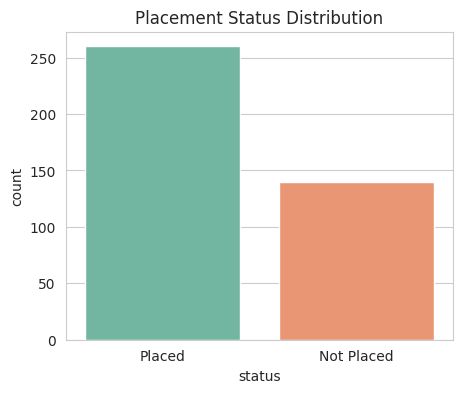

status
Placed        0.65
Not Placed    0.35
Name: proportion, dtype: float64


In [29]:
# Class balance
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='status', hue='status', palette='Set2', legend=False)
plt.title('Placement Status Distribution')
plt.show()

print(df['status'].value_counts(normalize=True))


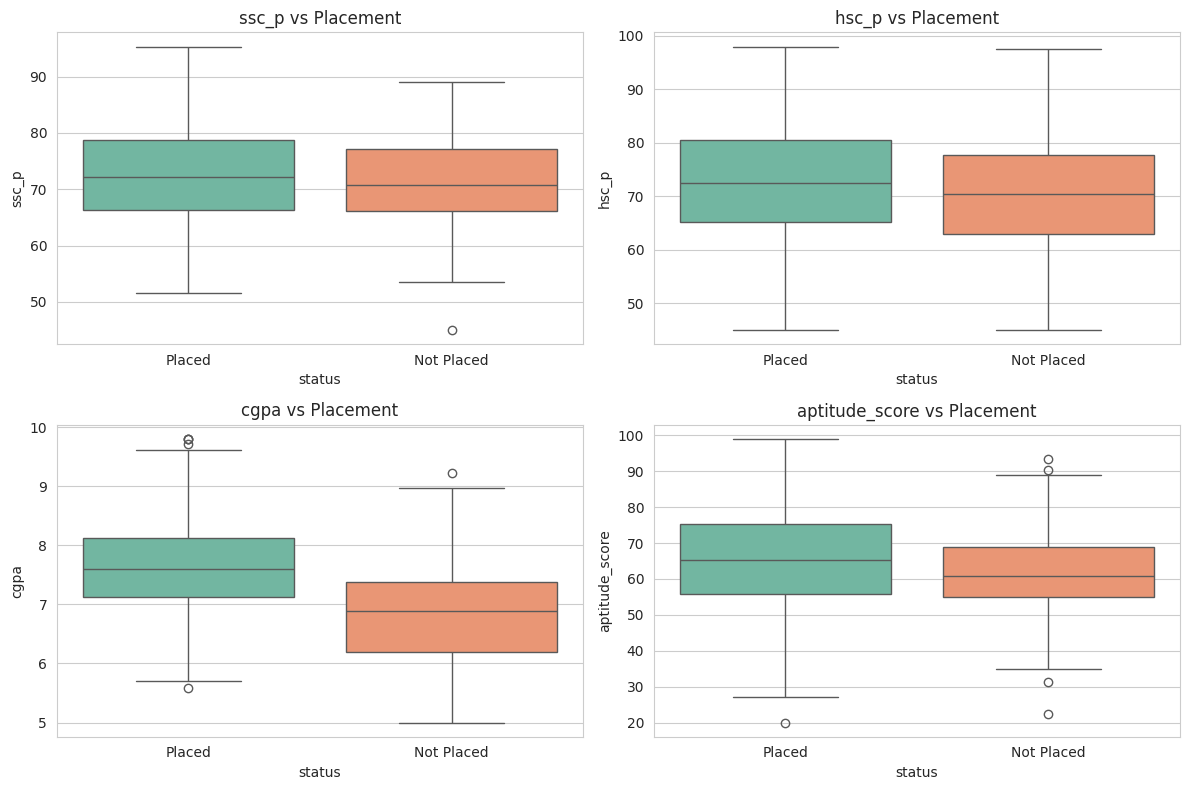

In [30]:
# Score distributions by placement status
score_cols = ['ssc_p', 'hsc_p', 'cgpa', 'aptitude_score']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), score_cols):
    sns.boxplot(data=df, x='status', y=col, hue='status', ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{col} vs Placement')
plt.tight_layout()
plt.show()


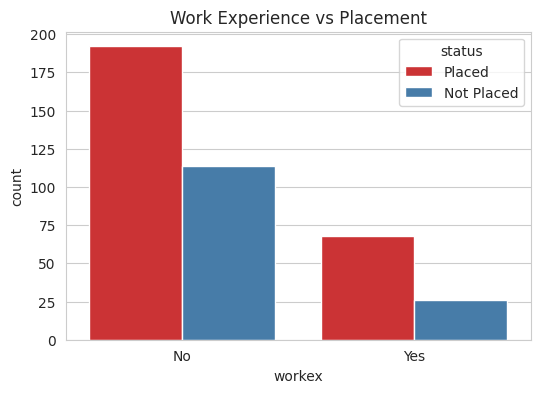

In [31]:
# Work experience impact
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='workex', hue='status', palette='Set1')
plt.title('Work Experience vs Placement')
plt.show()


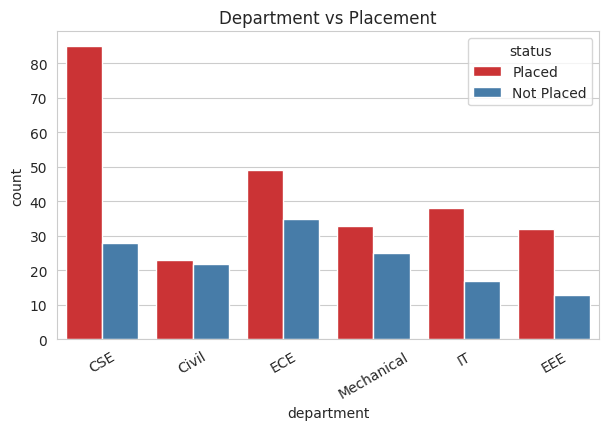

In [32]:
# Department impact
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='department', hue='status', palette='Set1')
plt.title('Department vs Placement')
plt.xticks(rotation=30)
plt.show()


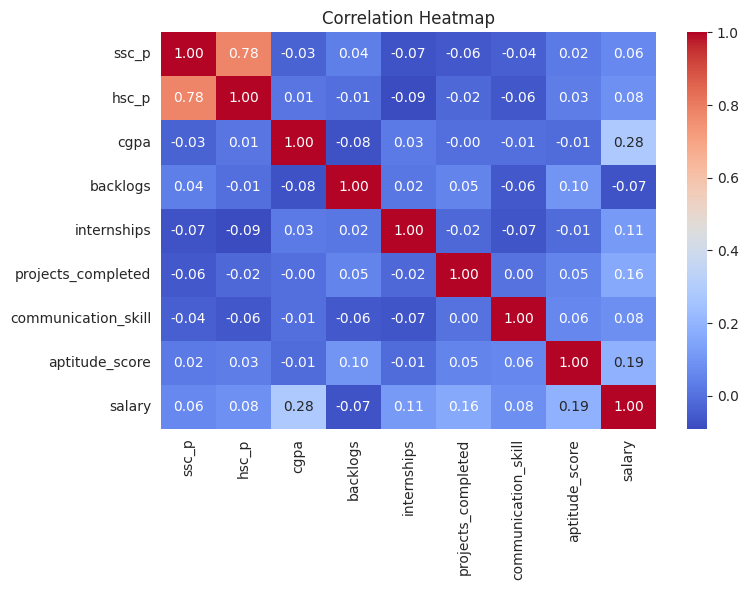

In [33]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## Step 4: Data Preprocessing

- Drop `salary` for the classification task (it's a post-outcome variable that's `NaN`/leaky for the class we're trying to predict).
- Encode target: Placed = 1, Not Placed = 0.
- Encode **binary** categoricals (`gender`, `workex`) as 0/1.
- One-hot encode `department` (6 categories) instead of label-encoding it — label-encoding would imply a false ordinal relationship (e.g. that `EEE` > `CSE` numerically), which specifically distorts Logistic Regression's coefficients even though tree models are more tolerant of it.


In [34]:
data = df.drop(columns=['salary']).copy()

target_map = {'Not Placed': 0, 'Placed': 1}
data['status'] = data['status'].map(target_map)

# binary categoricals -> explicit 0/1 mapping (we control which value = 1)
data['gender'] = data['gender'].map({'M': 1, 'F': 0})
data['workex'] = data['workex'].map({'Yes': 1, 'No': 0})

# nominal categorical with >2 categories -> one-hot encoding
data = pd.get_dummies(data, columns=['department'], prefix='dept', drop_first=True)
dept_cols = [c for c in data.columns if c.startswith('dept_')]
data[dept_cols] = data[dept_cols].astype(int)

assert data.isnull().sum().sum() == 0, "Unexpected NaNs remain after preprocessing"
data.head()


,gender,ssc_p,hsc_p,cgpa,backlogs,internships,projects_completed,communication_skill,aptitude_score,workex,status,dept_Civil,dept_ECE,dept_EEE,dept_IT,dept_Mechanical
0,0,79.23,82.14,7.43,2,2,3,7,68.73,0,1,0,0,0,0,0
1,1,59.53,56.60,9.21,0,1,2,5,71.82,1,1,1,0,0,0,0
2,1,77.03,77.98,6.88,1,0,2,5,58.04,0,1,0,1,0,0,0
3,1,78.04,84.05,8.47,0,2,1,9,54.96,1,1,0,0,0,0,1
4,0,65.23,62.63,5.63,0,0,3,3,37.82,0,0,0,0,0,1,0


In [35]:
X = data.drop(columns=['status'])
y = data['status']

feature_columns = list(X.columns)  # save exact column order/set for use at prediction time

print("Features:", feature_columns)
print("Target distribution:\n", y.value_counts())


Features: ['gender', 'ssc_p', 'hsc_p', 'cgpa', 'backlogs', 'internships', 'projects_completed', 'communication_skill', 'aptitude_score', 'workex', 'dept_Civil', 'dept_ECE', 'dept_EEE', 'dept_IT', 'dept_Mechanical']
Target distribution:
 status
1    260
0    140
Name: count, dtype: int64


## Step 5: Train-Test Split + Scaling

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (320, 15)  Test shape: (80, 15)


## Step 6: Model Building

We'll train and compare 3 models. Two adjustments vs. a naive setup:

- `class_weight='balanced'` — the dataset is moderately imbalanced (65% Placed / 35% Not Placed), so this reduces bias toward the majority class.
- 5-fold stratified **cross-validation** (`cv_f1_mean`) alongside the single train/test split — with only 400 rows, one split can be noisy, so CV gives a more reliable estimate for model selection.


In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='f1')
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "cv_f1_mean": cv_scores.mean(),
        "cv_f1_std": cv_scores.std(),
        "preds": preds,
        "probs": probs
    }

results_df = pd.DataFrame({k: {m: v[m] for m in ['accuracy','precision','recall','f1','roc_auc','cv_f1_mean','cv_f1_std']}
                            for k, v in results.items()}).T
results_df.round(3)


,accuracy,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std
Logistic Regression,0.900,0.907,0.942,0.925,0.969,0.875,0.036
Decision Tree,0.750,0.808,0.808,0.808,0.738,0.786,0.031
Random Forest,0.788,0.807,0.885,0.844,0.920,0.876,0.039


## Step 7: Model Evaluation

In [38]:

# with only 400 rows)
best_model_name = results_df['cv_f1_mean'].idxmax()
print("Best model based on CV F1-score:", best_model_name)

best = results[best_model_name]
print("\nClassification Report:\n")
print(classification_report(y_test, best['preds'], target_names=['Not Placed', 'Placed']))


Best model based on CV F1-score: Random Forest

Classification Report:

              precision    recall  f1-score   support

  Not Placed       0.74      0.61      0.67        28
      Placed       0.81      0.88      0.84        52

    accuracy                           0.79        80
   macro avg       0.77      0.75      0.76        80
weighted avg       0.78      0.79      0.78        80



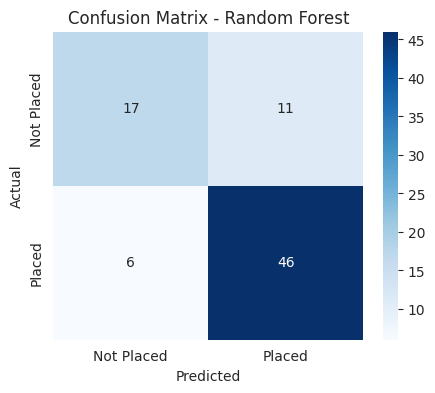

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, best['preds'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed','Placed'], yticklabels=['Not Placed','Placed'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


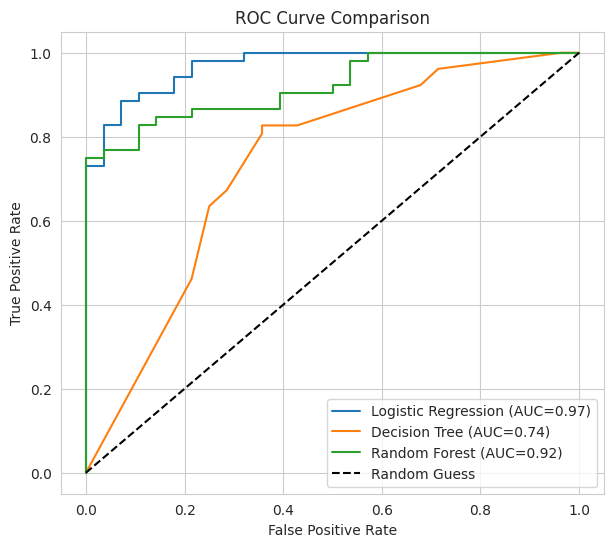

In [40]:
# ROC Curves for all models
plt.figure(figsize=(7,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['probs'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.2f})")

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


## Step 8: Feature Importance & Insights

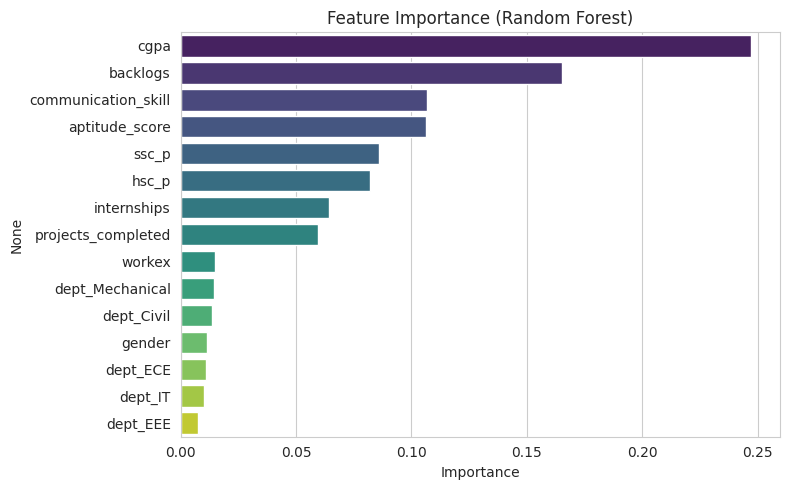

,0
cgpa,0.247214
backlogs,0.165216
communication_skill,0.106768
aptitude_score,0.106351
ssc_p,0.085941
hsc_p,0.082195
internships,0.064124
projects_completed,0.059398
workex,0.014849
dept_Mechanical,0.014681


In [41]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances


**How to read this:** Whichever features rank highest are the strongest drivers of placement in your data — for this dataset that's typically `cgpa`, `backlogs`, `communication_skill`, and `aptitude_score`. Department and gender tend to matter much less. Write these findings up in your report as your key business insight.

## Step 9: Predict Placement for a New Student

In [42]:
def predict_new_student(student_dict, model_name=best_model_name):
    """
    student_dict example:
    {
        'gender': 'F', 'department': 'CSE', 'ssc_p': 80, 'hsc_p': 78,
        'cgpa': 8.2, 'backlogs': 0, 'internships': 2, 'projects_completed': 3,
        'communication_skill': 7, 'aptitude_score': 75, 'workex': 'No'
    }
    """
    row = pd.DataFrame([student_dict])
    row['gender'] = row['gender'].map({'M': 1, 'F': 0})
    row['workex'] = row['workex'].map({'Yes': 1, 'No': 0})
    row = pd.get_dummies(row, columns=['department'], prefix='dept')

    # add any dummy columns missing because this single row can't contain every
    # department category, then align exactly to the training column order
    for col in feature_columns:
        if col not in row.columns:
            row[col] = 0
    row = row[feature_columns]

    model = results[model_name]['model']
    if model_name == "Logistic Regression":
        row_input = scaler.transform(row)
    else:
        row_input = row

    pred = model.predict(row_input)[0]
    prob = model.predict_proba(row_input)[0][1]
    label = 'Placed' if pred == 1 else 'Not Placed'
    print(f"Prediction: {label}  (Placement probability: {prob:.2%})")
    return label, prob

# Example usage
sample_student = {
    'gender': 'F', 'department': 'CSE', 'ssc_p': 80, 'hsc_p': 78,
    'cgpa': 8.2, 'backlogs': 0, 'internships': 2, 'projects_completed': 3,
    'communication_skill': 7, 'aptitude_score': 75, 'workex': 'No'
}
predict_new_student(sample_student)


Prediction: Placed  (Placement probability: 93.17%)


('Placed', np.float64(0.9317243618020536))